In [2]:
# Cell 1 — Install
!pip install vnstock pandas numpy matplotlib squarify scikit-learn ipython tensorflow

In [3]:
# Cell 2 — Import
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import squarify

from IPython.display import display

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [4]:
# Cell 3 — Tham số
import tensorflow as tf
import random
import numpy as np

RF_ANNUAL = 0.045
TRADING_DAYS = 252

LSTM_UNITS = 256
GRU_UNITS = 256
EPOCHS = 100
BATCH_SIZE = 32
WINDOW_SIZE = 30
SEED = 42

TRAIN_START = "2015-01-01"
TRAIN_END   = "2024-12-31"
TEST_START  = "2025-01-01"
TEST_END    = "2025-12-31"

# Fix seed
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [30]:
# Cell 4 — Chọn ngành / tập mã train model

from data.industry_tickers import INDUSTRY_TICKERS

# Chọn 1 hoặc nhiều ngành ở đây
SELECTED_INDUSTRIES = ["Thép"]
# SELECTED_INDUSTRIES = ["Ngân hàng"]
# SELECTED_INDUSTRIES = ["Thép", "Vật liệu xây dựng"]

selected_tickers = []

for industry in SELECTED_INDUSTRIES:
    selected_tickers.extend(INDUSTRY_TICKERS[industry])

# Xóa mã trùng
selected_tickers = sorted(list(set(selected_tickers)))

print("Ngành đã chọn:", SELECTED_INDUSTRIES)
print("Tổng số mã:", len(selected_tickers))
print(selected_tickers)

Ngành đã chọn: ['Thép']
Tổng số mã: 41
['BCA', 'BVG', 'CBI', 'DFC', 'DTL', 'GDA', 'HLA', 'HMC', 'HMG', 'HPG', 'HSG', 'HSV', 'ITQ', 'KKC', 'KMT', 'KTL', 'KVC', 'MEL', 'MHL', 'NKG', 'PAS', 'POM', 'SHA', 'SHI', 'SMC', 'SSM', 'TDS', 'TIS', 'TLH', 'TMG', 'TNA', 'TNB', 'TNI', 'TNS', 'TTH', 'TTS', 'TVN', 'VCA', 'VDT', 'VGL', 'VGS']


In [31]:
# Cell 5 — Load dữ liệu giá theo ngành đã chọn
import time
import pandas as pd
from vnstock import Vnstock

all_data = []
failed_tickers = []

print(f"Đang tải dữ liệu cho {len(selected_tickers)} mã:", SELECTED_INDUSTRIES)

request_count = 0
window_start = time.time()

for i, ticker in enumerate(selected_tickers, start=1):
    success = False
    retry_count = 0
    max_retry = 5

    while not success and retry_count < max_retry:
        try:
            stock = Vnstock().stock(symbol=ticker, source="KBS")
            df = stock.quote.history(
                start=TRAIN_START,
                end=TEST_END,
                interval="1D"
            )

            if df is None or df.empty:
                print(f"[{i}/{len(selected_tickers)}] Không có dữ liệu: {ticker}")
                failed_tickers.append(ticker)
                success = True
                break

            df = df.copy()
            df["ticker"] = ticker

            if "time" not in df.columns:
                if "date" in df.columns:
                    df["time"] = df["date"]
                elif "datetime" in df.columns:
                    df["time"] = df["datetime"]
                else:
                    raise ValueError(f"{ticker}: Không tìm thấy cột thời gian.")

            keep_cols = [
                c for c in ["time", "open", "high", "low", "close", "volume", "ticker"]
                if c in df.columns
            ]
            df = df[keep_cols]

            all_data.append(df)
            print(f"[{i}/{len(selected_tickers)}] OK: {ticker} - {len(df)} dòng")
            success = True

            request_count += 1
            time.sleep(3.2)

            if request_count >= 18:
                elapsed = time.time() - window_start
                if elapsed < 60:
                    sleep_time = 60 - elapsed
                    print(f"Đang nghỉ {sleep_time:.1f}s để tránh rate limit...")
                    time.sleep(sleep_time)

                request_count = 0
                window_start = time.time()

        except Exception as e:
            msg = str(e).lower()
            retry_count += 1

            if "rate limit" in msg or "429" in msg or "forbidden" in msg:
                wait_time = 30
                print(f"[{i}/{len(selected_tickers)}] Bị chặn ở {ticker} -> nghỉ {wait_time}s ({retry_count}/{max_retry})")
                time.sleep(wait_time)
            else:
                print(f"[{i}/{len(selected_tickers)}] Lỗi {ticker}: {e}")
                failed_tickers.append(ticker)
                break

    if not success and ticker not in failed_tickers:
        failed_tickers.append(ticker)

if all_data:
    raw_data = pd.concat(all_data, ignore_index=True)
    print("\n=== HOÀN TẤT ===")
    print("Raw data shape:", raw_data.shape)
    print("Số mã lỗi / không có dữ liệu:", len(failed_tickers))
    if failed_tickers:
        print("Danh sách lỗi:", failed_tickers)
    display(raw_data.head())
else:
    raise ValueError("Không tải được dữ liệu cho bất kỳ mã nào.")

Đang tải dữ liệu cho 41 mã: ['Thép']
[1/41] OK: BCA - 1074 dòng
[2/41] OK: BVG - 1738 dòng
[3/41] OK: CBI - 999 dòng
[4/41] OK: DFC - 682 dòng
[5/41] OK: DTL - 2042 dòng
[6/41] OK: GDA - 581 dòng
[7/41] OK: HLA - 539 dòng
[8/41] OK: HMC - 2539 dòng
[9/41] OK: HMG - 172 dòng
[10/41] OK: HPG - 2567 dòng
[11/41] OK: HSG - 2567 dòng
[12/41] OK: HSV - 1172 dòng
[13/41] OK: ITQ - 2564 dòng
[14/41] OK: KKC - 1803 dòng
[15/41] OK: KMT - 591 dòng
[16/41] OK: KTL - 1321 dòng
[17/41] OK: KVC - 2562 dòng
[18/41] OK: MEL - 951 dòng
[19/41] OK: MHL - 972 dòng
[20/41] OK: NKG - 2567 dòng
[21/41] OK: PAS - 1321 dòng
[22/41] OK: POM - 2161 dòng
[23/41] OK: SHA - 2482 dòng
[24/41] OK: SHI - 2567 dòng
[25/41] OK: SMC - 2544 dòng
[26/41] OK: SSM - 1185 dòng
[27/41] OK: TDS - 1956 dòng
[28/41] OK: TIS - 2244 dòng
[29/41] OK: TLH - 2567 dòng
[30/41] OK: TMG - 619 dòng
[31/41] OK: TNA - 2235 dòng
[32/41] OK: TNB - 1397 dòng
[33/41] OK: TNI - 2151 dòng
[34/41] OK: TNS - 1218 dòng
[35/41] OK: TTH - 2297 dòng
[

,time,open,high,low,close,volume,ticker
0,2021-09-16 07:00:00,15.4,15.4,15.4,15.4,1800,BCA
1,2021-09-17 07:00:00,17.7,17.7,17.7,17.7,114900,BCA
2,2021-09-20 07:00:00,20.3,20.3,18.8,18.9,658100,BCA
3,2021-09-21 07:00:00,19.3,20.4,18.5,18.6,760800,BCA
4,2021-09-22 07:00:00,18.0,18.0,16.8,16.8,350800,BCA


In [32]:
# Cell 6 — Pivot thành bảng giá đóng cửa
pivot_df_clean = raw_data.pivot_table(
    index="time",
    columns="ticker",
    values="close",
    aggfunc="last"
).sort_index()

pivot_df_clean.index = pd.to_datetime(pivot_df_clean.index)
pivot_df_clean = pivot_df_clean.sort_index()

print("Shape:", pivot_df_clean.shape)
display(pivot_df_clean.head())
display(pivot_df_clean.tail())

Shape: (2569, 41)


ticker,BCA,BVG,CBI,DFC,DTL,GDA,HLA,HMC,HMG,HPG,...,TNB,TNI,TNS,TTH,TTS,TVN,VCA,VDT,VGL,VGS
time,,,,,,,,,,,,,,,,,,,,,
2015-09-28 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.8,2.48,NaN,3.02,...,3.12,NaN,NaN,NaN,NaN,NaN,2.41,NaN,NaN,2.16
2015-09-29 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.8,2.48,NaN,3.01,...,3.28,NaN,NaN,NaN,NaN,NaN,2.32,NaN,NaN,2.16
2015-09-30 07:00:00,NaN,NaN,NaN,NaN,8.5,NaN,0.8,2.45,NaN,3.04,...,3.55,NaN,NaN,NaN,NaN,NaN,2.63,NaN,NaN,2.16
2015-10-01 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.8,2.45,NaN,3.07,...,3.65,NaN,NaN,NaN,NaN,NaN,2.84,5.15,NaN,2.16
2015-10-02 07:00:00,NaN,NaN,NaN,NaN,8.0,NaN,0.8,2.45,NaN,3.09,...,3.76,NaN,NaN,NaN,NaN,NaN,2.84,NaN,NaN,2.12


ticker,BCA,BVG,CBI,DFC,DTL,GDA,HLA,HMC,HMG,HPG,...,TNB,TNI,TNS,TTH,TTS,TVN,VCA,VDT,VGL,VGS
time,,,,,,,,,,,,,,,,,,,,,
2025-12-25 07:00:00,13.9,NaN,NaN,NaN,12.70,16.2,NaN,11.75,NaN,26.25,...,NaN,5.22,NaN,2.3,NaN,7.4,8.36,NaN,NaN,26.1
2025-12-26 07:00:00,14.9,2.7,NaN,NaN,12.80,16.4,NaN,11.80,NaN,26.90,...,NaN,5.11,3.0,2.3,NaN,7.5,8.16,NaN,19.1,26.5
2025-12-29 07:00:00,13.8,NaN,NaN,NaN,12.95,16.2,NaN,11.70,NaN,26.70,...,9.9,5.16,NaN,2.4,NaN,7.5,8.15,NaN,NaN,26.2
2025-12-30 07:00:00,13.9,NaN,NaN,NaN,13.10,16.2,NaN,11.70,NaN,26.50,...,NaN,5.14,NaN,2.3,NaN,7.4,8.18,NaN,NaN,26.3
2025-12-31 07:00:00,13.9,NaN,NaN,NaN,13.20,16.1,NaN,11.70,NaN,26.40,...,NaN,5.02,NaN,2.3,NaN,7.4,8.17,NaN,NaN,25.9


In [33]:
# Cell 7 — Tính daily returns an toàn hơn
# Fill missing trên GIÁ trước, không fill trên return
price_filled = pivot_df_clean.ffill()

# Tính return
returns_df = price_filled.pct_change()

# Xử lý inf/nan
returns_df = returns_df.replace([np.inf, -np.inf], np.nan)

# Loại dòng đầu tiên và các dòng còn thiếu
returns_df = returns_df.dropna(how="any")

print("Kích thước returns_df:", returns_df.shape)
display(returns_df.head())

print("Mean daily return:")
display(returns_df.mean())

print("Max daily return:")
display(returns_df.max().sort_values(ascending=False).head(10))

print("Min daily return:")
display(returns_df.min().sort_values().head(10))

Kích thước returns_df: (580, 41)


ticker,BCA,BVG,CBI,DFC,DTL,GDA,HLA,HMC,HMG,HPG,...,TNB,TNI,TNS,TTH,TTS,TVN,VCA,VDT,VGL,VGS
time,,,,,,,,,,,,,,,,,,,,,
2023-09-08 07:00:00,-0.016393,0.000000,0.013158,0.000000,0.004219,-0.005577,0.0,0.013830,0.000000,0.003227,...,0.0,0.000000,0.0,0.000000,0.0,0.013812,-0.009193,0.000000,0.0,0.026892
2023-09-11 07:00:00,0.000000,-0.034483,-0.064935,0.000000,0.008403,-0.092752,0.0,-0.027282,0.000000,-0.026195,...,0.0,-0.024316,0.0,-0.051282,0.0,-0.025886,-0.005155,0.000000,0.0,-0.042022
2023-09-12 07:00:00,0.033333,0.035714,0.000000,0.025851,-0.008333,-0.044698,0.0,0.014024,0.000000,0.026899,...,0.0,-0.006231,0.0,0.027027,0.0,0.000000,0.009326,0.142514,0.0,0.060394
2023-09-13 07:00:00,-0.016129,0.000000,0.000000,0.000000,0.008403,-0.040319,0.0,-0.009574,0.400477,-0.011949,...,0.0,0.000000,0.0,-0.026316,0.0,0.012587,-0.004107,0.000000,0.0,0.067746
2023-09-14 07:00:00,0.032787,-0.034483,0.013889,0.000000,-0.012500,-0.069502,0.0,0.000000,0.000000,-0.021395,...,0.0,-0.012539,0.0,-0.027027,0.0,-0.026243,-0.002062,0.000000,0.0,-0.029197


Mean daily return:


ticker
BCA    0.002384
BVG    0.000160
CBI    0.002683
DFC    0.001497
DTL   -0.000765
GDA   -0.000353
HLA   -0.000489
HMC    0.000502
HMG    0.000710
HPG    0.000480
HSG   -0.000194
HSV    0.000767
ITQ    0.000284
KKC    0.000913
KMT    0.000364
KTL    0.000573
KVC   -0.000137
MEL    0.000370
MHL   -0.000051
NKG    0.000118
PAS   -0.000659
POM    0.000216
SHA   -0.000264
SHI    0.000201
SMC    0.000588
SSM   -0.000370
TDS    0.000547
TIS    0.000410
TLH   -0.000813
TMG    0.001872
TNA   -0.001009
TNB    0.001935
TNI    0.001009
TNS    0.000625
TTH   -0.000357
TTS   -0.000139
TVN    0.000456
VCA   -0.000010
VDT   -0.000518
VGL    0.000517
VGS    0.001340
dtype: float64

Max daily return:


ticker
KTL    0.485929
HMG    0.400477
TTS    0.400000
POM    0.387900
TNB    0.378947
VDT    0.260653
DFC    0.257221
HLA    0.250000
TMG    0.197897
HSV    0.196970
dtype: float64

Min daily return:


ticker
TNB   -0.400000
KTL   -0.399912
VDT   -0.399894
TTS   -0.350000
TMG   -0.250776
HMG   -0.247660
CBI   -0.217949
TDS   -0.204545
HLA   -0.200000
DFC   -0.183371
dtype: float64

In [34]:
# Cell 8 — Tính Sharpe từng mã và chọn top mã để train
rf_daily = RF_ANNUAL / TRADING_DAYS

mean_ret = returns_df.mean()
std_ret = returns_df.std().replace(0, np.nan)

sharpe_ratio = ((mean_ret - rf_daily) / std_ret).dropna().sort_values(ascending=False)

TOP_N = 10
top_10_symbols = sharpe_ratio.head(TOP_N).index.tolist()

print(f"Top {TOP_N} mã theo Sharpe từ ngành:", SELECTED_INDUSTRIES)
print(top_10_symbols)

display(sharpe_ratio.head(TOP_N))

Top 10 mã theo Sharpe từ ngành: ['Thép']
['BCA', 'CBI', 'DFC', 'VGS', 'TNI', 'TMG', 'TNB', 'HMC', 'KKC', 'HPG']


ticker
BCA    0.049659
CBI    0.043063
DFC    0.042114
VGS    0.036488
TNI    0.034966
TMG    0.033035
TNB    0.031066
HMC    0.020482
KKC    0.019298
HPG    0.017934
dtype: float64

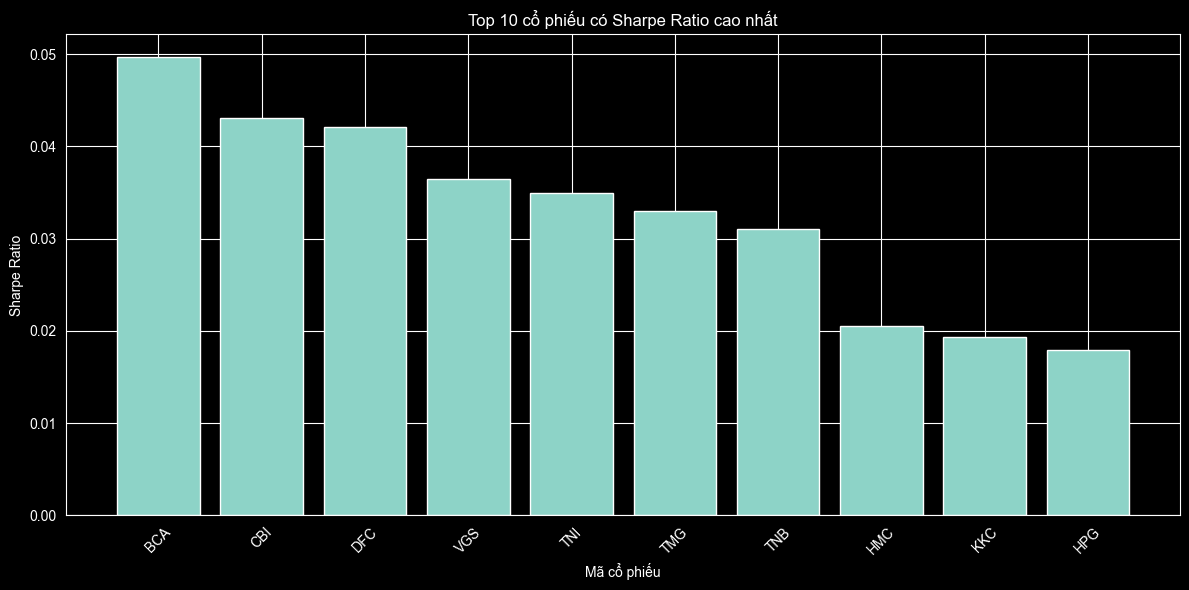

In [35]:
# Cell 9 — Vẽ biểu đồ top 10 Sharpe
top10_sharpe = sharpe_ratio.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_sharpe.index, top10_sharpe.values)
plt.title("Top 10 cổ phiếu có Sharpe Ratio cao nhất")
plt.xlabel("Mã cổ phiếu")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Cell 10 — Lọc dữ liệu top 10
price_top10 = pivot_df_clean[top_10_symbols].copy()
returns_top10 = returns_df[top_10_symbols].copy()

print("price_top10:", price_top10.shape)
print("returns_top10:", returns_top10.shape)

display(price_top10.head())
display(returns_top10.head())

price_top10: (2569, 10)
returns_top10: (580, 10)


ticker,BCA,CBI,DFC,VGS,TNI,TMG,TNB,HMC,KKC,HPG
time,,,,,,,,,,
2015-09-28 07:00:00,NaN,NaN,NaN,2.16,NaN,NaN,3.12,2.48,NaN,3.02
2015-09-29 07:00:00,NaN,NaN,NaN,2.16,NaN,NaN,3.28,2.48,6.06,3.01
2015-09-30 07:00:00,NaN,NaN,NaN,2.16,NaN,NaN,3.55,2.45,NaN,3.04
2015-10-01 07:00:00,NaN,NaN,NaN,2.16,NaN,NaN,3.65,2.45,NaN,3.07
2015-10-02 07:00:00,NaN,NaN,NaN,2.12,NaN,NaN,3.76,2.45,NaN,3.09


ticker,BCA,CBI,DFC,VGS,TNI,TMG,TNB,HMC,KKC,HPG
time,,,,,,,,,,
2023-09-08 07:00:00,-0.016393,0.013158,0.000000,0.026892,0.000000,0.000000,0.0,0.013830,0.000000,0.003227
2023-09-11 07:00:00,0.000000,-0.064935,0.000000,-0.042022,-0.024316,0.016956,0.0,-0.027282,0.000000,-0.026195
2023-09-12 07:00:00,0.033333,0.000000,0.025851,0.060394,-0.006231,-0.003372,0.0,0.014024,0.066667,0.026899
2023-09-13 07:00:00,-0.016129,0.000000,0.000000,0.067746,0.000000,0.000000,0.0,-0.009574,0.000000,-0.011949
2023-09-14 07:00:00,0.032787,0.013889,0.000000,-0.029197,-0.012539,-0.147180,0.0,0.000000,0.000000,-0.021395


In [37]:
# Cell 11 — Chia train/test từ PRICE rồi làm sạch trước
train_prices = price_top10.loc[TRAIN_START:TRAIN_END].copy()
test_prices  = price_top10.loc[TEST_START:TEST_END].copy()

# Fill missing trên giá
train_prices = train_prices.sort_index().ffill().bfill()
test_prices  = test_prices.sort_index().ffill().bfill()

# Tính return từ giá đã fill
train_returns = train_prices.pct_change().replace([np.inf, -np.inf], np.nan)
test_returns  = test_prices.pct_change().replace([np.inf, -np.inf], np.nan)

# Bỏ dòng đầu do pct_change
train_returns = train_returns.dropna(how="any")
test_returns  = test_returns.dropna(how="any")

print("train_prices:", train_prices.shape)
print("test_prices :", test_prices.shape)
print("train_returns:", train_returns.shape)
print("test_returns :", test_returns.shape)

print("NaN train_prices:", train_prices.isna().sum().sum())
print("NaN test_prices :", test_prices.isna().sum().sum())
print("NaN train_returns:", train_returns.isna().sum().sum())
print("NaN test_returns :", test_returns.isna().sum().sum())

display(train_prices.head())
display(train_returns.head())

train_prices: (2320, 10)
test_prices : (249, 10)
train_returns: (2319, 10)
test_returns : (248, 10)
NaN train_prices: 0
NaN test_prices : 0
NaN train_returns: 0
NaN test_returns : 0


ticker,BCA,CBI,DFC,VGS,TNI,TMG,TNB,HMC,KKC,HPG
time,,,,,,,,,,
2015-09-28 07:00:00,15.4,8.2,5.68,2.16,12.47,7.14,3.12,2.48,6.06,3.02
2015-09-29 07:00:00,15.4,8.2,5.68,2.16,12.47,7.14,3.28,2.48,6.06,3.01
2015-09-30 07:00:00,15.4,8.2,5.68,2.16,12.47,7.14,3.55,2.45,6.06,3.04
2015-10-01 07:00:00,15.4,8.2,5.68,2.16,12.47,7.14,3.65,2.45,6.06,3.07
2015-10-02 07:00:00,15.4,8.2,5.68,2.12,12.47,7.14,3.76,2.45,6.06,3.09


ticker,BCA,CBI,DFC,VGS,TNI,TMG,TNB,HMC,KKC,HPG
time,,,,,,,,,,
2015-09-29 07:00:00,0.0,0.0,0.0,0.000000,0.0,0.0,0.051282,0.000000,0.000000,-0.003311
2015-09-30 07:00:00,0.0,0.0,0.0,0.000000,0.0,0.0,0.082317,-0.012097,0.000000,0.009967
2015-10-01 07:00:00,0.0,0.0,0.0,0.000000,0.0,0.0,0.028169,0.000000,0.000000,0.009868
2015-10-02 07:00:00,0.0,0.0,0.0,-0.018519,0.0,0.0,0.030137,0.000000,0.000000,0.006515
2015-10-05 07:00:00,0.0,0.0,0.0,0.018868,0.0,0.0,0.000000,-0.016327,0.051155,0.016181


In [38]:
# Cell 12 — Feature engineering + scaling + sequence (horizon=5)
from sklearn.preprocessing import StandardScaler

HORIZON = 5  # dùng trung bình return 5 ngày tới

def compute_rsi(price_df, period=14):
    delta = price_df.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period, min_periods=period).mean()
    avg_loss = loss.rolling(period, min_periods=period).mean()

    rs = avg_gain / (avg_loss + 1e-9)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def build_features(price_df, return_df):
    common_idx = price_df.index.intersection(return_df.index)
    price_df = price_df.loc[common_idx].copy()
    return_df = return_df.loc[common_idx].copy()

    price_df = price_df.replace([np.inf, -np.inf], np.nan).ffill().bfill()
    return_df = return_df.replace([np.inf, -np.inf], np.nan).fillna(0)

    feat_list = []

    ret_1 = return_df.copy()
    ret_1.columns = [f"{c}_ret1" for c in ret_1.columns]
    feat_list.append(ret_1)

    ret_5 = price_df.pct_change(5)
    ret_5.columns = [f"{c}_ret5" for c in ret_5.columns]
    feat_list.append(ret_5)

    ret_10 = price_df.pct_change(10)
    ret_10.columns = [f"{c}_ret10" for c in ret_10.columns]
    feat_list.append(ret_10)

    ma5_ratio = price_df / (price_df.rolling(5, min_periods=5).mean() + 1e-9) - 1
    ma5_ratio.columns = [f"{c}_ma5_ratio" for c in ma5_ratio.columns]
    feat_list.append(ma5_ratio)

    ma10_ratio = price_df / (price_df.rolling(10, min_periods=10).mean() + 1e-9) - 1
    ma10_ratio.columns = [f"{c}_ma10_ratio" for c in ma10_ratio.columns]
    feat_list.append(ma10_ratio)

    vol5 = return_df.rolling(5, min_periods=5).std()
    vol5.columns = [f"{c}_vol5" for c in vol5.columns]
    feat_list.append(vol5)

    vol10 = return_df.rolling(10, min_periods=10).std()
    vol10.columns = [f"{c}_vol10" for c in vol10.columns]
    feat_list.append(vol10)

    mom5 = price_df.pct_change(5)
    mom5.columns = [f"{c}_mom5" for c in mom5.columns]
    feat_list.append(mom5)

    rsi14 = compute_rsi(price_df, period=14) / 100.0
    rsi14.columns = [f"{c}_rsi14" for c in rsi14.columns]
    feat_list.append(rsi14)

    features = pd.concat(feat_list, axis=1)
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.dropna(axis=0, how="any")

    return features

train_features = build_features(train_prices, train_returns)
test_features = build_features(test_prices, test_returns)

print("train_features shape:", train_features.shape)
print("test_features shape :", test_features.shape)
display(train_features.head())

scaler = StandardScaler()

train_features_scaled = pd.DataFrame(
    scaler.fit_transform(train_features),
    index=train_features.index,
    columns=train_features.columns
)

test_features_scaled = pd.DataFrame(
    scaler.transform(test_features),
    index=test_features.index,
    columns=test_features.columns
)

train_target_returns = train_returns.loc[train_features_scaled.index].copy()
test_target_returns = test_returns.loc[test_features_scaled.index].copy()

def create_sequences_and_targets(features_df, target_returns_df, window_size, horizon=5):
    X, y, dates = [], [], []

    feat_values = features_df.values.astype(np.float32)
    target_values = target_returns_df.values.astype(np.float32)
    idx = features_df.index

    for i in range(len(features_df) - window_size - horizon + 1):
        X.append(feat_values[i:i + window_size])
        y.append(target_values[i + window_size:i + window_size + horizon].mean(axis=0))
        dates.append(idx[i + window_size + horizon - 1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), pd.Index(dates)

X_train, y_train_target, train_seq_dates = create_sequences_and_targets(
    train_features_scaled, train_target_returns, WINDOW_SIZE, horizon=HORIZON
)

X_test, y_test_target, test_seq_dates = create_sequences_and_targets(
    test_features_scaled, test_target_returns, WINDOW_SIZE, horizon=HORIZON
)

print("X_train shape:", X_train.shape)
print("y_train_target shape:", y_train_target.shape)
print("X_test shape :", X_test.shape)
print("y_test_target shape :", y_test_target.shape)

train_features shape: (2305, 90)
test_features shape : (234, 90)


,BCA_ret1,CBI_ret1,DFC_ret1,VGS_ret1,TNI_ret1,TMG_ret1,TNB_ret1,HMC_ret1,KKC_ret1,HPG_ret1,...,BCA_rsi14,CBI_rsi14,DFC_rsi14,VGS_rsi14,TNI_rsi14,TMG_rsi14,TNB_rsi14,HMC_rsi14,KKC_rsi14,HPG_rsi14
time,,,,,,,,,,,,,,,,,,,,,
2015-10-19 07:00:00,0.0,0.0,0.0,-0.022624,0.0,0.0,-0.013699,0.016598,0.000000,0.000000,...,0.0,0.0,0.0,0.500000,0.0,0.0,0.579208,0.434783,0.342593,0.711111
2015-10-20 07:00:00,0.0,0.0,0.0,0.000000,0.0,0.0,0.044444,0.000000,-0.081784,-0.018750,...,0.0,0.0,0.0,0.500000,0.0,0.0,0.554974,0.500000,0.284615,0.604167
2015-10-21 07:00:00,0.0,0.0,0.0,0.000000,0.0,0.0,0.127660,-0.016327,0.062753,-0.006369,...,0.0,0.0,0.0,0.500000,0.0,0.0,0.628821,0.416667,0.360825,0.553191
2015-10-22 07:00:00,0.0,0.0,0.0,0.023148,0.0,0.0,0.000000,0.016598,-0.059048,0.006410,...,0.0,0.0,0.0,0.581818,0.0,0.0,0.610092,0.500000,0.326087,0.553191
2015-10-23 07:00:00,0.0,0.0,0.0,0.000000,0.0,0.0,0.049528,-0.028571,0.000000,0.012739,...,0.0,0.0,0.0,0.549020,0.0,0.0,0.644351,0.451613,0.254296,0.543478


X_train shape: (2271, 30, 90)
y_train_target shape: (2271, 10)
X_test shape : (200, 30, 90)
y_test_target shape : (200, 10)


In [39]:
# Cell 13 — Sharpe loss
from tensorflow.keras import backend as K

LAMBDA_ENTROPY = 0.01

def sharpe_loss(y_true, y_pred):
    portfolio_returns = K.sum(y_true * y_pred, axis=1)
    portfolio_returns = portfolio_returns - (RF_ANNUAL / TRADING_DAYS)

    mean_returns = K.mean(portfolio_returns)
    std_returns = K.std(portfolio_returns)

    sharpe = mean_returns / (std_returns + 1e-9)

    entropy = -K.sum(y_pred * K.log(y_pred + 1e-9), axis=1)
    entropy = K.mean(entropy)

    return -sharpe - LAMBDA_ENTROPY * entropy

In [40]:
# Cell 14 — Build model nâng cấp
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_lstm_gru_model(timesteps, n_features, n_assets):
    model = Sequential([
        Input(shape=(timesteps, n_features)),

        LSTM(
            96,
            return_sequences=True,
            activation="tanh",
            recurrent_activation="sigmoid"
        ),
        Dropout(0.2),

        GRU(
            48,
            return_sequences=False,
            activation="tanh",
            recurrent_activation="sigmoid"
        ),
        Dropout(0.2),

        Dense(64, activation="relu"),
        Dropout(0.1),

        Dense(n_assets, activation="softmax")
    ])
    return model

model_lstm_gru = build_lstm_gru_model(
    timesteps=X_train.shape[1],
    n_features=X_train.shape[2],
    n_assets=y_train_target.shape[1]
)

model_lstm_gru.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=sharpe_loss
)

model_lstm_gru.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 96)         │        71,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 48)             │        21,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,618 (377.41 KB)

 Trainable params: 96,618 (377.41 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Cell 15 — Train model nhiều seed
import os
import random
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def train_one_run(seed, X_train, y_train_target):
    set_seed(seed)

    model = build_lstm_gru_model(
        timesteps=X_train.shape[1],
        n_features=X_train.shape[2],
        n_assets=y_train_target.shape[1]
    )

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss=sharpe_loss
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-5
        )
    ]

    history = model.fit(
        X_train,
        y_train_target,
        epochs=100,
        batch_size=32,
        shuffle=False,
        verbose=0,
        validation_split=0.2,
        callbacks=callbacks
    )

    return model, history

In [42]:
# Cell 16 — Chạy nhiều seed, chọn model tốt nhất trên test
results_runs = []

best_model = None
best_sharpe = -1e9
best_seed = None
best_history = None
best_portfolio_returns = None
best_pred_weights_test = None

seed_list = [7, 21, 42, 99, 123]

for seed in seed_list:
    model, history = train_one_run(seed, X_train, y_train_target)

    pred_weights_test = model.predict(X_test, verbose=0)

    weights_test_df = pd.DataFrame(
        pred_weights_test,
        index=test_seq_dates,
        columns=top_10_symbols
    )

    y_test_df = pd.DataFrame(
        y_test_target,
        index=test_seq_dates,
        columns=top_10_symbols
    )

    portfolio_returns = (weights_test_df * y_test_df).sum(axis=1)

    run_er = portfolio_returns.mean() * TRADING_DAYS
    run_std = portfolio_returns.std() * np.sqrt(TRADING_DAYS)
    run_sharpe = (run_er - RF_ANNUAL) / (run_std + 1e-12)

    results_runs.append({
        "seed": seed,
        "Lợi nhuận TB năm": run_er,
        "Độ lệch chuẩn năm": run_std,
        "Sharpe": run_sharpe
    })

    if run_sharpe > best_sharpe:
        best_sharpe = run_sharpe
        best_seed = seed
        best_model = model
        best_history = history
        best_portfolio_returns = portfolio_returns.copy()
        best_pred_weights_test = pred_weights_test.copy()

results_runs_df = pd.DataFrame(results_runs).sort_values("Sharpe", ascending=False).reset_index(drop=True)

print("Best seed:", best_seed)
print("Best Sharpe:", best_sharpe)
display(results_runs_df)

portfolio_returns_lstm_dynamic = best_portfolio_returns.copy()

weights_lstm_gru_avg = best_pred_weights_test.mean(axis=0)
results_LSTM_GRU = pd.DataFrame({
    "Asset": top_10_symbols,
    "Weight": weights_lstm_gru_avg
}).sort_values("Weight", ascending=False).reset_index(drop=True)

print("Tổng trọng số trung bình:", results_LSTM_GRU["Weight"].sum())
display(results_LSTM_GRU)

Best seed: 42
Best Sharpe: 4.05786824164418


,seed,Lợi nhuận TB năm,Độ lệch chuẩn năm,Sharpe
0,42,0.596075,0.135804,4.057868
1,7,0.419121,0.105505,3.546001
2,99,0.464772,0.134202,3.127912
3,21,0.357365,0.101504,3.077356
4,123,0.218198,0.119699,1.446942


Tổng trọng số trung bình: 1.0


,Asset,Weight
0,TNB,0.241495
1,DFC,0.129940
2,TMG,0.108996
3,VGS,0.093860
4,HMC,0.089781
5,HPG,0.086322
6,CBI,0.086319
7,TNI,0.070468
8,KKC,0.063658
9,BCA,0.029162


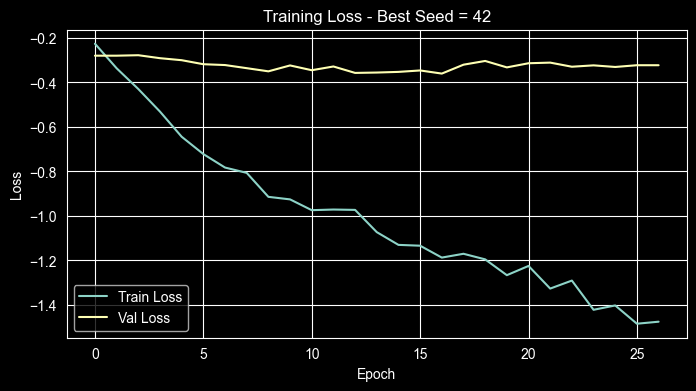

In [44]:
# Cell 17 — Vẽ training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(best_history.history["loss"], label="Train Loss")
plt.plot(best_history.history["val_loss"], label="Val Loss")
plt.title(f"Training Loss - Best Seed = {best_seed}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

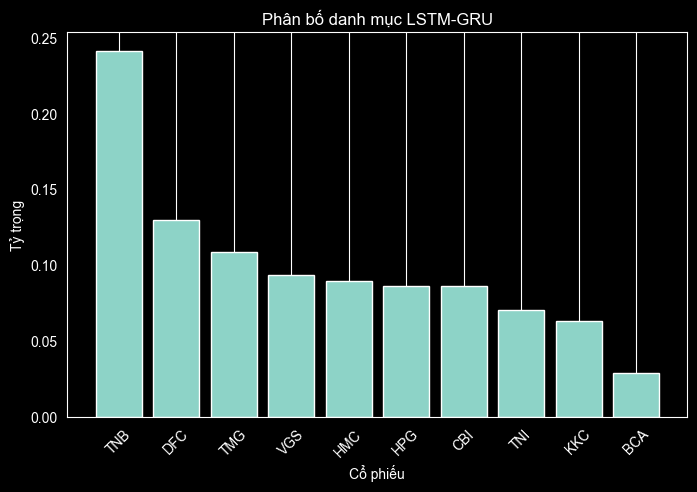

In [45]:
# Cell 18 — Vẽ phân bố danh mục LSTM-GRU
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results_LSTM_GRU["Asset"], results_LSTM_GRU["Weight"])

plt.title("Phân bố danh mục LSTM-GRU")
plt.xlabel("Cổ phiếu")
plt.ylabel("Tỷ trọng")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

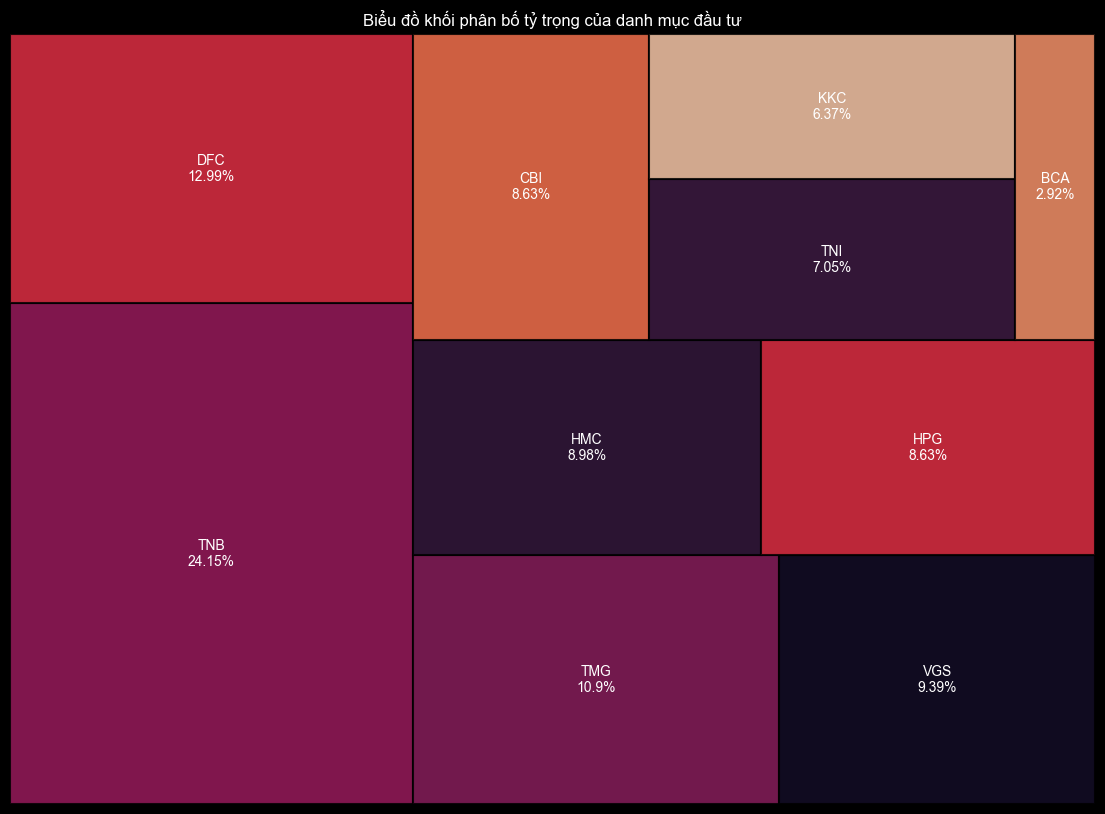

In [46]:
# Cell 19 — Treemap tỷ trọng danh mục
treemap_df = results_LSTM_GRU.copy()
treemap_df["Label"] = treemap_df["Asset"] + "\n" + (treemap_df["Weight"] * 100).round(2).astype(str) + "%"

plt.figure(figsize=(14, 10))
squarify.plot(
    sizes=treemap_df["Weight"],
    label=treemap_df["Label"],
    alpha=0.85,
    edgecolor="black",
    linewidth=1.5,
    text_kwargs={"fontsize": 10}
)
plt.axis("off")
plt.title("Biểu đồ khối phân bố tỷ trọng của danh mục đầu tư")
plt.show()

In [47]:
# Cell 20 — Hàm tính đặc trưng danh mục
def port_char(weights_df, returns_df, annualize=True, freq=TRADING_DAYS):
    er = returns_df.mean().reset_index()
    er.columns = ["Asset", "Er"]

    weights_merged = pd.merge(weights_df, er, on="Asset", how="left")
    weights_merged["Er"] = weights_merged["Er"].fillna(0.0)

    portfolio_er_daily = np.dot(weights_merged["Weight"], weights_merged["Er"])

    cov_matrix = returns_df.cov()
    asset_order = weights_merged["Asset"].tolist()
    cov_matrix = cov_matrix.loc[asset_order, asset_order]

    w = weights_merged["Weight"].values
    portfolio_std_daily = np.sqrt(np.dot(w, np.dot(cov_matrix, w)))

    if annualize:
        portfolio_er = portfolio_er_daily * freq
        portfolio_std_dev = portfolio_std_daily * np.sqrt(freq)
    else:
        portfolio_er = portfolio_er_daily
        portfolio_std_dev = portfolio_std_daily

    return portfolio_er, portfolio_std_dev

def port_char_from_series(portfolio_return_series, annualize=True, freq=TRADING_DAYS):
    portfolio_return_series = pd.Series(portfolio_return_series).dropna()

    er_daily = portfolio_return_series.mean()
    std_daily = portfolio_return_series.std()

    if annualize:
        er = er_daily * freq
        std = std_daily * np.sqrt(freq)
    else:
        er = er_daily
        std = std_daily

    return er, std

In [48]:
# Cell 21 — Hàm tính Sharpe danh mục
def sharpe_port(weights_df, returns_df, rf=RF_ANNUAL, freq=TRADING_DAYS):
    portfolio_er, portfolio_std_dev = port_char(
        weights_df,
        returns_df,
        annualize=True,
        freq=freq
    )
    sharpe_ratio = (portfolio_er - rf) / (portfolio_std_dev + 1e-12)
    return sharpe_ratio

def sharpe_from_series(portfolio_return_series, rf=RF_ANNUAL, freq=TRADING_DAYS):
    portfolio_er, portfolio_std_dev = port_char_from_series(
        portfolio_return_series,
        annualize=True,
        freq=freq
    )
    sharpe_ratio = (portfolio_er - rf) / (portfolio_std_dev + 1e-12)
    return sharpe_ratio

In [49]:
# Cell 22 — Allo_1: Phân bổ đều
Allo_1 = pd.DataFrame({
    "Asset": top_10_symbols,
    "Weight": [1 / len(top_10_symbols)] * len(top_10_symbols)
})

print("Tổng trọng số Allo_1:", Allo_1["Weight"].sum())
display(Allo_1)

Tổng trọng số Allo_1: 1.0


,Asset,Weight
0,BCA,0.1
1,CBI,0.1
2,DFC,0.1
3,VGS,0.1
4,TNI,0.1
5,TMG,0.1
6,TNB,0.1
7,HMC,0.1
8,KKC,0.1
9,HPG,0.1


In [50]:
# Cell 23 — Allo_2: Phân bổ 80-20
def build_allocation_80_20(train_returns):
    rf_daily = RF_ANNUAL / TRADING_DAYS

    mean_ret = train_returns.mean()
    std_ret = train_returns.std().replace(0, np.nan)
    sharpe_train = ((mean_ret - rf_daily) / std_ret).dropna().sort_values(ascending=False)

    ranked = sharpe_train.reset_index()
    ranked.columns = ["Asset", "Score"]

    n_assets = len(ranked)
    top_count = max(1, int(np.ceil(0.2 * n_assets)))
    bottom_count = n_assets - top_count

    top_weights = [0.8 / top_count] * top_count
    bottom_weights = [0.2 / bottom_count] * bottom_count if bottom_count > 0 else []

    ranked["Weight"] = top_weights + bottom_weights
    return ranked[["Asset", "Weight"]]

Allo_2 = build_allocation_80_20(train_returns)

print("Tổng trọng số Allo_2:", Allo_2["Weight"].sum())
display(Allo_2)

Tổng trọng số Allo_2: 1.0


,Asset,Weight
0,VGS,0.400
1,HPG,0.400
2,TMG,0.025
3,HMC,0.025
4,TNB,0.025
5,DFC,0.025
6,CBI,0.025
7,KKC,0.025
8,BCA,0.025
9,TNI,0.025


In [51]:
# Cell 24 — So sánh 3 chiến lược
Er_lstm, std_lstm = port_char_from_series(portfolio_returns_lstm_dynamic, annualize=True)
Er_1, std_1 = port_char(Allo_1, test_returns, annualize=True)
Er_2, std_2 = port_char(Allo_2, test_returns, annualize=True)

sharpe_lstm = sharpe_from_series(portfolio_returns_lstm_dynamic)
sharpe_1 = sharpe_port(Allo_1, test_returns)
sharpe_2 = sharpe_port(Allo_2, test_returns)

comparison_table = pd.DataFrame({
    "Chiến lược đầu tư": ["LSTM-GRU (Dynamic)", "Phân bổ đều", "Phân bổ 80-20"],
    "Lợi nhuận trung bình": [Er_lstm, Er_1, Er_2],
    "Độ lệch chuẩn": [std_lstm, std_1, std_2],
    "Hệ số Sharpe": [sharpe_lstm, sharpe_1, sharpe_2]
})

comparison_table_display = comparison_table.copy()
comparison_table_display["Lợi nhuận trung bình"] = comparison_table_display["Lợi nhuận trung bình"] * 100
comparison_table_display["Độ lệch chuẩn"] = comparison_table_display["Độ lệch chuẩn"] * 100

display(comparison_table_display.round(4))

,Chiến lược đầu tư,Lợi nhuận trung bình,Độ lệch chuẩn,Hệ số Sharpe
0,LSTM-GRU (Dynamic),59.6075,13.5804,4.0579
1,Phân bổ đều,40.7649,23.2241,1.5615
2,Phân bổ 80-20,19.3967,31.4120,0.4742


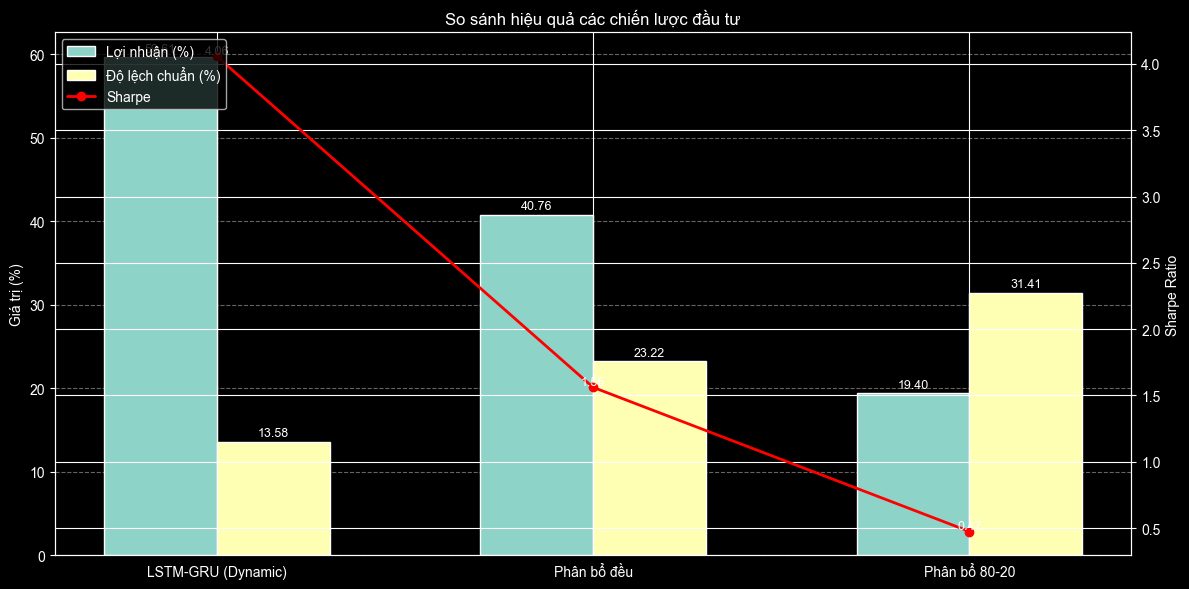

In [52]:
# Cell 25 — Biểu đồ gộp 3 metric (Dual Axis)

import numpy as np
import matplotlib.pyplot as plt

plot_df = comparison_table_display.copy()

categories = plot_df["Chiến lược đầu tư"].values
er_values = plot_df["Lợi nhuận trung bình"].values
std_values = plot_df["Độ lệch chuẩn"].values
sharpe_values = plot_df["Hệ số Sharpe"].values

x = np.arange(len(categories))
width = 0.3

fig, ax1 = plt.subplots(figsize=(12, 6))

# =========================================================
# 1. Trục Y bên trái: ER + STD (%)
# =========================================================
bars1 = ax1.bar(x - width/2, er_values, width, label="Lợi nhuận (%)")
bars2 = ax1.bar(x + width/2, std_values, width, label="Độ lệch chuẩn (%)")

ax1.set_ylabel("Giá trị (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Hiển thị số trên cột
for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# =========================================================
# 2. Trục Y bên phải: Sharpe
# =========================================================
ax2 = ax1.twinx()

line = ax2.plot(
    x,
    sharpe_values,
    color="red",
    marker="o",
    linewidth=2,
    label="Sharpe"
)

ax2.set_ylabel("Sharpe Ratio")

# Hiển thị số Sharpe
for i, v in enumerate(sharpe_values):
    ax2.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

# =========================================================
# 3. Title + legend
# =========================================================
plt.title("So sánh hiệu quả các chiến lược đầu tư")

# gộp legend 2 trục
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

plt.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

In [53]:
# Cell 26 — Kết luận nhanh
best_idx = comparison_table["Hệ số Sharpe"].idxmax()
best_strategy = comparison_table.loc[best_idx, "Chiến lược đầu tư"]

print("=== KẾT LUẬN NHANH ===")
print("Chiến lược có Sharpe cao nhất:", best_strategy)

display_table = (
    comparison_table_display
    .sort_values("Hệ số Sharpe", ascending=False)
    .reset_index(drop=True)
    .copy()
)

display_table["Lợi nhuận trung bình"] = display_table["Lợi nhuận trung bình"].map(lambda x: f"{x:.2f}%")
display_table["Độ lệch chuẩn"] = display_table["Độ lệch chuẩn"].map(lambda x: f"{x:.2f}%")
display_table["Hệ số Sharpe"] = display_table["Hệ số Sharpe"].map(lambda x: f"{x:.2f}")

display(display_table)

=== KẾT LUẬN NHANH ===
Chiến lược có Sharpe cao nhất: LSTM-GRU (Dynamic)


,Chiến lược đầu tư,Lợi nhuận trung bình,Độ lệch chuẩn,Hệ số Sharpe
0,LSTM-GRU (Dynamic),59.61%,13.58%,4.06
1,Phân bổ đều,40.76%,23.22%,1.56
2,Phân bổ 80-20,19.40%,31.41%,0.47
